In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import finufft

In [ ]:
# ---== Global Variables ==--- #
num_threads = 1

In [17]:
# ---== wave vector generation ==--- #

# We always assume the domain is [0, 1]^2

def generate_k_vectors(num_per_dim):
    """
    Generate wavevectors on a uniform 2D grid using fftfreq
    """

    kx = np.fft.fftfreq(num_per_dim, d=1.0/num_per_dim)
    ky = np.fft.fftfreq(num_per_dim, d=1.0/num_per_dim)
    
    return np.array(np.meshgrid(kx, ky, indexing='ij'))


In [18]:
# ---== inital point pattern generation ==--- #

# Important: the domain is always [-pi, pi]^2

def random_point_pattern(N):
    return np.random.uniform(-np.pi, np.pi, size=(N, 2)) # shape : (rN, 2)

# ------
# the following methods generate approximately N points and exactly N points if N = k^2, for some k

def uniform_point_pattern(N):
    rN = round(np.sqrt(N))
    space = np.linspace(-np.pi+0.01, np.pi-0.01, rN)
    return np.array(np.meshgrid(space, space)).reshape(2, -1).T # shape : (rN, 2)

def perturbed_point_pattern(N, eps=0.05):
    uniform = uniform_point_pattern(N)
    rN = uniform.shape[0]
    pert_x = eps*np.random.uniform(-1, 1, size=(rN,))
    pert_y = eps*np.random.uniform(-1, 1, size=(rN,))
    uniform[:, 0] += pert_x
    uniform[:, 1] += pert_y
    return uniform  # shape : (rN, 2)

In [19]:
def compute_rho(k, r):
    N = r.shape[0]
    rx = np.ascontiguousarray(r[:, 0])
    ry = np.ascontiguousarray(r[:, 1])
    c = np.ones(N, dtype=np.complex128)
    rho = finufft.nufft2d1(rx, ry, c, k[0].shape, isign=+1,nthreads=num_threads, modeord=1) # (sqrtM, sqrtM)
    rho[0,0] = 1e-4
    return rho

# for optimization purposes
def compute_S_rho(rho, N):
    return np.abs(rho)**2 / N

def compute_S(k, r):
    N = r.shape[0]
    return compute_S_rho(compute_rho(k, r), N)

def compute_S0(k, D, H, alpha, K_cutoff):
    k_magnitude = 2*np.sqrt(k[0]**2+k[1]**2)  # (sqrtM, sqrtM)
    S0 = np.where(k_magnitude < K_cutoff, D * (1 - H) * (k_magnitude**alpha) + H, 1.0)
    return S0

def objective_function(x, k, S0_k):
    N = x.shape[0] // 2
    r = x.reshape(N, 2)
    r = np.mod(r+np.pi, 2*np.pi) - np.pi
    S_kr = compute_S(k, r)
    return np.sum((S_kr - S0_k)**2)

def gradient_function(x, k, S0_k):
    N = x.shape[0] // 2
    r = x.reshape(N, 2)
    r = np.mod(r+np.pi, 2*np.pi) - np.pi
    grad = np.zeros_like(r) # (N, 2)
    rho = compute_rho(k, r) # (sqrtM, sqrtM)
    S_kr = compute_S_rho(rho, N) # (sqrtM, sqrtM)
    factor = -4.j/N * ((S_kr - S0_k) * rho) # (sqrtM, sqrtM)
    C_hat_x = k[0] * factor # (sqrtM, sqrtM)
    C_hat_y = k[1] * factor
    rx = np.ascontiguousarray(r[:, 0])
    ry = np.ascontiguousarray(r[:, 1])
    grad[:, 0] = np.real(finufft.nufft2d2(rx, ry, C_hat_x, isign=-1,modeord=1,nthreads=num_threads))
    grad[:, 1] = np.real(finufft.nufft2d2(rx, ry, C_hat_y, isign=-1,modeord=1,nthreads=num_threads))
    return grad.ravel()

In [ ]:
# ---== Visualization ==--- #

def plot_wave_vectors(k):
    plt.figure(figsize=(6, 6))
    plt.scatter(k[0], k[1], marker="x", color="green")
    plt.xlabel("$k_x$")
    plt.ylabel("$k_y$")
    plt.title("Wave vectors")
    plt.show()

def plot_particles(r, title):
    plt.figure(figsize=(6, 6))
    r = np.mod(r+np.pi, 2*np.pi) - np.pi
    plt.scatter(r[:, 0], r[:, 1], c="blue", s=20)
    plt.title(title)
    plt.gca().set_aspect('equal')
    plt.show()

def plot_structure_factor(r, k, K_cutoff, S0_k, title):
    S_kr = compute_S(k, r).ravel()
    k_magnitude = np.sqrt(k[0]**2+k[1]**2).ravel()
    plt.figure(figsize=(8, 5))
    plt.scatter(k_magnitude/(K_cutoff/2), S_kr, color="red", label="Computed S(k)")
    plt.scatter(k_magnitude/(K_cutoff/2), S0_k.ravel(), color="green", label="Computed S_0(k)", marker="x")
    plt.xlabel("|k|/K")
    plt.ylabel("S(k)")
    plt.title(title)
    plt.legend()
    plt.show()

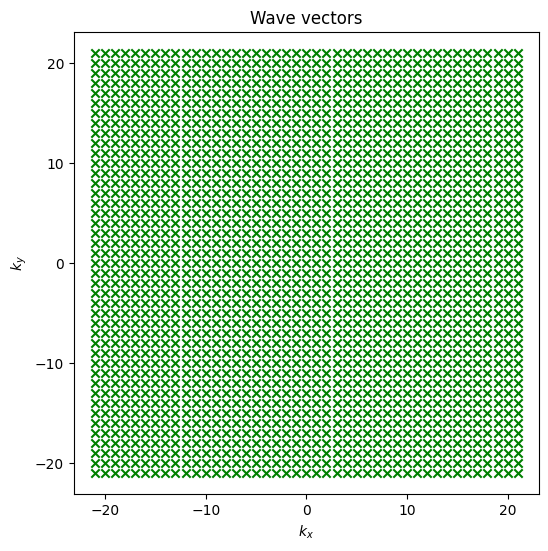

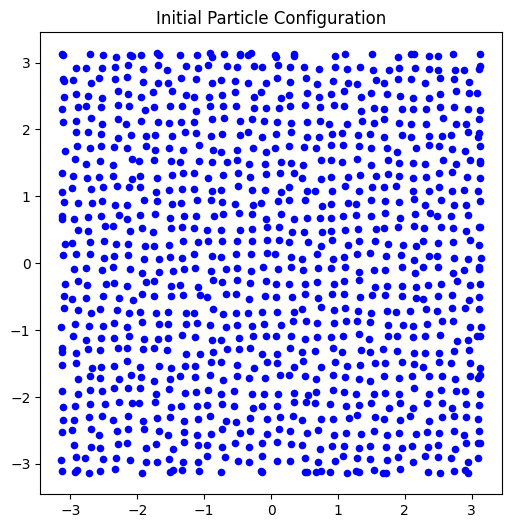

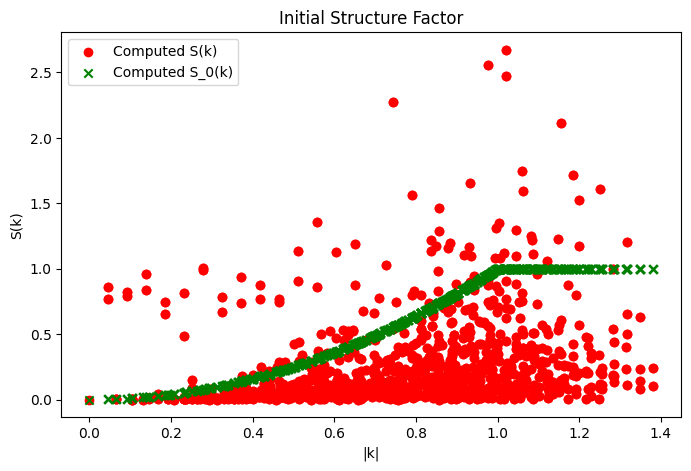

Value before optimizing:  510.7102965525561
         Current function value: 0.000004
         Iterations: 1000
         Function evaluations: 1005
         Gradient evaluations: 1005
  message: Maximum number of iterations has been exceeded.
  success: False
   status: 1
      fun: 4.292668542502225e-06
        x: [-3.098e+00 -3.017e+00 ...  3.272e+00  3.032e+00]
      nit: 1000
      jac: [ 4.038e-04  3.057e-04 ...  7.721e-04 -9.569e-04]
 hess_inv: [[ 6.680e-01 -8.068e-03 ...  3.007e-02  1.017e-01]
            [-8.068e-03  6.354e-01 ...  3.249e-02  4.755e-02]
            ...
            [ 3.007e-02  3.249e-02 ...  5.862e-01  3.618e-02]
            [ 1.017e-01  4.755e-02 ...  3.618e-02  6.207e-01]]
     nfev: 1005
     njev: 1005
parameters saved to parms.csv
phi saved to point_patterns/pp.npy


c:\Users\eioer\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\optimize\_minimize.py:733: OptimizeWarning: Maximum number of iterations has been exceeded.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)


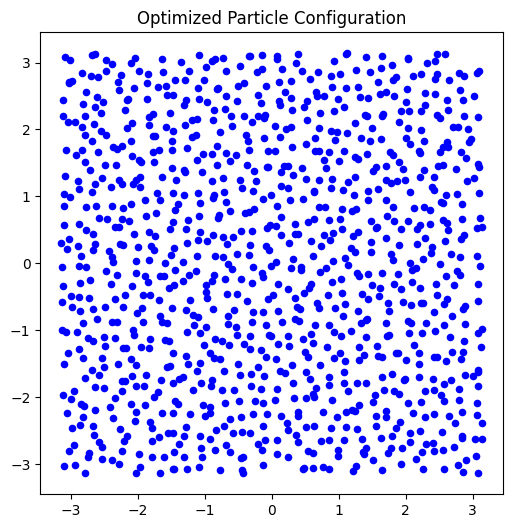

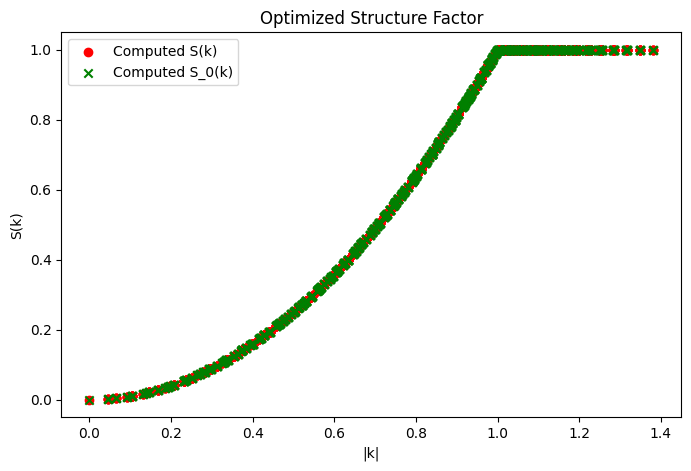

In [ ]:
np.random.seed(0)  # For reproducibility

# ---== Parameters ==--- #

N = 1000
M = 100     

# Target structure factor parameters
H = 1e-4
alpha = 2.
K_cutoff = 43
D = np.pow(K_cutoff, -alpha)

r_init = perturbed_point_pattern(N)
# since some point pattern generation algos dont give exactly N
N = r_init.shape[0] 

k = generate_k_vectors(K_cutoff)
M = k.shape[1]*k.shape[2]

# Plot wave vectors used:
plot_wave_vectors(k)

# target structure factor precomputation
S0_k = compute_S0(k, D, H, alpha, K_cutoff)

# Plot before optimization
plot_particles(r_init, "Initial Particle Configuration")
plot_structure_factor(r_init, k, K_cutoff, S0_k, "Initial Structure Factor")

print("Value before optimizing: ", objective_function(r_init.flatten(), k, S0_k))

# ---== Run Optimization ==--- #
res = minimize(
    fun=objective_function,
    x0=r_init.flatten(),
    jac=gradient_function,
    args=(k, S0_k),
    method="BFGS",
    options={"disp": True, "maxiter": 1000},
    tol=1e-8
)

# ---== Postprocess ==--- #

r_opt = res.x.reshape(N, 2)  # Final particle positions
print(res)

# Save point pattern:
outfile = f"point_patterns/pp.npy"
np.save(outfile, r_opt)
with open("point_patterns/parms.csv", 'w') as f:
        f.write("N, M, D, H, K_cutoff, alpha\n")
        f.write(f"{N},{M},{D},{H},{K_cutoff},{alpha}\n")
print("parameters saved to parms.csv")
print(f"phi saved to {outfile}")

# Plot after optimization
plot_particles(r_opt, "Optimized Particle Configuration")
plot_structure_factor(r_opt, k, K_cutoff, S0_k, "Optimized Structure Factor")
